# Emotion Detection from Text Using LSTM

### 1. Problem Statement 
Emotion Detection from Text aims to identify the underlying emotional state expressed in a 
given sentence or document. Unlike sentiment analysis (positive/negative), emotion detection 
classifies text into multiple emotional categories such as: 
    ● Happy 
    ● Sad 
    ● Anger 
    ● Fear 
    ● Surprise 
    ● Neutral

## 2. Data Collection

#### Dataset Selection: Emotion Dataset from Kaggle

The **Emotion Dataset from Kaggle** is selected for building the emotion detection model. It contains labeled text samples with different emotions such as **joy, sadness, anger, fear, love,** and **surprise**. This publicly available dataset is widely used for training and evaluating emotion classification models in Natural Language Processing (NLP).


In [1]:
# Data handling
import pandas as pd
import numpy as np

# visulization
import matplotlib.pyplot as plt
import seaborn as sns

# Regular Expressions
import re

# Data Splitting and Label Encoding
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,LabelBinarizer,MultiLabelBinarizer

# Deep Learning Libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input,Embedding,SimpleRNN,Dense,GRU,
                                    TimeDistributed,Dropout,BatchNormalization)

# Text Preprocessing
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score,
    RocCurveDisplay
)

In [2]:
# # Standard Library
# import re
# import string

# # Data Manipulation
# import pandas as pd
# import numpy as np

# # Visualization
# import matplotlib.pyplot as plt

# # Natural Language Processing
# import nltk
# from nltk.corpus import stopwords
# from nltk.tokenize import word_tokenize

# # Scikit-learn
# # Data Splitting
# from sklearn.model_selection import train_test_split

# # Preprocessing
# from sklearn.preprocessing import LabelEncoder,LabelBinarizer,MultiLabelBinarizer

# # Evaluation Metrics
# from sklearn.metrics import (accuracy_score,confusion_matrix,ConfusionMatrixDisplay,classification_report,
#                             roc_curve, roc_auc_score,RocCurveDisplay)

# # TensorFlow / Keras
# import tensorflow as tf

# # Model
# from tensorflow.keras.models import Sequential

# # Layers
# from tensorflow.keras.layers import Input,Embedding,LSTM,GRU,Dense,Dropout,TimeDistributed,BatchNormalization

# # Text Preprocessing
# from tensorflow.keras.preprocessing.text import Tokenizer
# from tensorflow.keras.preprocessing.sequence import pad_sequences

# # Utilities
# from tensorflow.keras.utils import to_categorical

In [3]:
# Load Dataset
df = pd.read_csv(r"D:\Deep Learning\NLP Project\emotions\dataset.csv")
df

,text,label,emotion
0,i feel awful about it too because it s my job ...,0,sadness
1,im alone i feel awful,0,sadness
2,ive probably mentioned this before but i reall...,1,joy
3,i was feeling a little low few days back,0,sadness
4,i beleive that i am much more sensitive to oth...,2,love
...,...,...,...
416804,that was what i felt when i was finally accept...,1,joy
416805,i take every day as it comes i m just focussin...,4,fear
416806,i just suddenly feel that everything was fake,0,sadness
416807,im feeling more eager than ever to claw back w...,1,joy


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416809 entries, 0 to 416808
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   text     416809 non-null  object
 1   label    416809 non-null  int64 
 2   emotion  416809 non-null  object
dtypes: int64(1), object(2)
memory usage: 9.5+ MB


In [5]:
df.shape

(416809, 3)

In [6]:
# Count the number of samples in each emotion class
df['emotion'].value_counts()

emotion
joy         141067
sadness     121187
anger        57317
fear         47712
love         34554
surprise     14972
Name: count, dtype: int64

C:\Users\Ravikant\AppData\Local\Temp\ipykernel_29372\2538362404.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


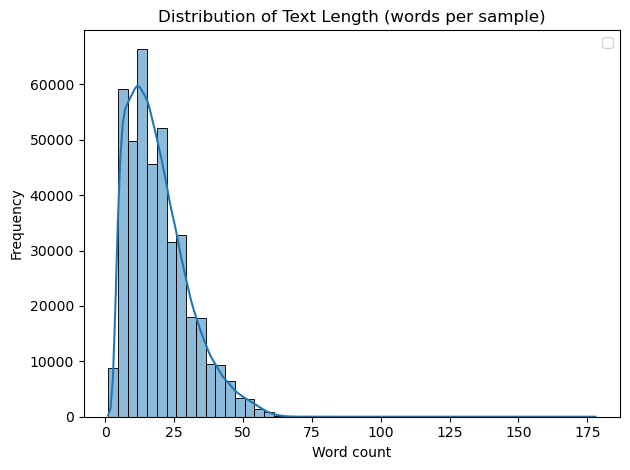

count    416809.000000
mean         19.211015
std          11.051049
min           1.000000
25%          11.000000
50%          17.000000
75%          25.000000
max         178.000000
Name: text, dtype: float64


In [7]:
word_counts = df["text"].str.split().apply(len)

sns.histplot(word_counts, bins=50, kde=True)
plt.title("Distribution of Text Length (words per sample)")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

print(word_counts.describe())


### 3. Data Preprocessing

### Text Cleaning

In [8]:
def clean_text(review):
    text = str(review).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)   # Remove URLs
    text = re.sub(r"@\w+", " ", text)               # Remove mentions
    text = re.sub(r"[^a-z\s]", " ", text)           # Remove numbers, punctuation, emojis, special characters
    text = re.sub(r"\s+", " ", text).strip()        # Remove extra spaces
    return text

# Apply text cleaning
df["clean_text"] = df["text"].apply(clean_text)

# Remove empty reviews after cleaning
df = df[df["clean_text"].str.len() > 0]

# Remove duplicate reviews
df = df.drop_duplicates(subset="clean_text").reset_index(drop=True)

print("Shape after cleaning & dedup:", df.shape)

# Display sample cleaned data
df[["text", "clean_text","label", "emotion"]].head()

Shape after cleaning & dedup: (393822, 4)


,text,clean_text,label,emotion
0,i feel awful about it too because it s my job ...,i feel awful about it too because it s my job ...,0,sadness
1,im alone i feel awful,im alone i feel awful,0,sadness
2,ive probably mentioned this before but i reall...,ive probably mentioned this before but i reall...,1,joy
3,i was feeling a little low few days back,i was feeling a little low few days back,0,sadness
4,i beleive that i am much more sensitive to oth...,i beleive that i am much more sensitive to oth...,2,love


In [9]:
# def clean_text(text):
#     # Lowercase
#     text = text.lower()

#     # Remove URLs
#     text = re.sub(r'http\S+|www\S+', '', text)

#     # Remove emojis
#     text = re.sub(r'[\U00010000-\U0010ffff]', '', text)

#     # Remove numbers
#     text = re.sub(r'\d+', '', text)

#     # Remove punctuation
#     text = text.translate(str.maketrans('', '', string.punctuation))

#     # Remove special characters
#     text = re.sub(r'[^a-zA-Z\s]', '', text)

#     # Remove extra spaces
#     text = re.sub(r'\s+', ' ', text).strip()

#     return text

# df["clean_text"] = df["text"].apply(clean_text)


### Tokenization

In [10]:
# Tokenization :Splitting sentences into  words or tokens 
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['clean_text'])
print("Words:")
print(tokenizer.word_index)

Words:
{'i': 1, 'feel': 2, 'and': 3, 'to': 4, 'the': 5, 'a': 6, 'feeling': 7, 'that': 8, 'of': 9, 'my': 10, 'in': 11, 'it': 12, 'like': 13, 'so': 14, 'for': 15, 'im': 16, 'have': 17, 'me': 18, 'but': 19, 'was': 20, 'is': 21, 'am': 22, 'this': 23, 'with': 24, 'not': 25, 'be': 26, 'about': 27, 'as': 28, 'on': 29, 'you': 30, 'just': 31, 'when': 32, 'at': 33, 'or': 34, 'all': 35, 'more': 36, 'because': 37, 'do': 38, 'really': 39, 'can': 40, 'up': 41, 't': 42, 'know': 43, 'very': 44, 'are': 45, 'by': 46, 'been': 47, 'out': 48, 'myself': 49, 'what': 50, 'if': 51, 'time': 52, 'how': 53, 'get': 54, 'little': 55, 'will': 56, 'had': 57, 'now': 58, 'from': 59, 'people': 60, 'they': 61, 'being': 62, 'would': 63, 'he': 64, 'want': 65, 'her': 66, 'one': 67, 'think': 68, 'them': 69, 'still': 70, 'some': 71, 'even': 72, 'ive': 73, 'who': 74, 'much': 75, 'an': 76, 'we': 77, 'its': 78, 'life': 79, 'him': 80, 'there': 81, 'something': 82, 's': 83, 'things': 84, 'bit': 85, 'make': 86, 'way': 87, 'm': 88, 

In [11]:
#Convert sentences to number sequences
sequence = tokenizer.texts_to_sequences(df['clean_text']) 
print(sequence[:10])

[[1, 2, 456, 27, 12, 93, 37, 12, 83, 10, 324, 4, 54, 80, 11, 6, 1170, 4, 2951, 3, 12, 31, 253, 42, 568, 136], [16, 213, 1, 2, 456], [73, 300, 1345, 23, 167, 19, 1, 39, 38, 2, 367, 9, 49, 15, 170, 1112, 41, 24, 10, 176, 225, 4762, 9, 5161, 3, 3401, 1508], [1, 20, 7, 6, 55, 387, 188, 163, 100], [1, 15796, 8, 1, 22, 75, 36, 1819, 4, 115, 1499, 118, 3, 926, 4, 26, 36, 1011], [1, 162, 49, 315, 24, 3635, 37, 1, 2, 8, 81, 21, 776, 6, 274, 27, 338, 67, 242, 62, 81, 15, 292, 115, 3, 2173, 15, 292, 115, 3, 1, 17, 820, 8, 23, 21, 25, 107, 5, 857], [1, 22, 67, 9, 139, 60, 74, 119, 13, 91, 4, 5, 1421, 21, 114, 541, 51, 30, 40, 26, 81, 15, 76, 873, 34, 36], [1, 2, 272, 610, 27, 23, 28, 23, 101, 47, 6, 193, 52, 352], [1, 20, 1359, 24, 117, 456, 118, 3, 20, 333, 175, 344, 84, 27, 25, 6804, 10, 3, 10, 2167, 1459, 3, 77, 3270, 140, 97, 20, 11, 66, 812, 31, 307, 4, 1229, 183, 32, 97, 1678, 48, 66, 526], [1, 2, 14, 1382, 19, 463, 33, 5, 223, 52]]


### Padding Sequences

In [12]:
# Sequence Padding: Padding or truncating sequences to maintain uniform input length
pad_seq = pad_sequences(sequence)
print(pad_seq)

[[   0    0    0 ...   42  568  136]
 [   0    0    0 ...    1    2  456]
 [   0    0    0 ...    3 3401 1508]
 ...
 [   0    0    0 ...  182   20  585]
 [   0    0    0 ...  100   29 1429]
 [   0    0    0 ...    2 1060  466]]


In [13]:
# Feature (input)
X = pad_seq
X

array([[   0,    0,    0, ...,   42,  568,  136],
       [   0,    0,    0, ...,    1,    2,  456],
       [   0,    0,    0, ...,    3, 3401, 1508],
       ...,
       [   0,    0,    0, ...,  182,   20,  585],
       [   0,    0,    0, ...,  100,   29, 1429],
       [   0,    0,    0, ...,    2, 1060,  466]],
      shape=(393822, 178), dtype=int32)

In [14]:
# label Encoding Target column
le = LabelEncoder()
y = le.fit_transform(df['emotion'])
print("Encoded classes",le.classes_)

Encoded classes ['anger' 'fear' 'joy' 'love' 'sadness' 'surprise']


# Model Building

In [15]:
# Train Test split 
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(315057, 178)
(78765, 178)
(315057,)
(78765,)


In [16]:
# vocab is the unique words in sentences.
vocab_size = len(tokenizer.word_index)+1
vocab_size

75300

In [31]:
# Model Architecture
model = Sequential()
# Input layer
model.add(Input(shape=(X_train.shape[1],)))
# Embedding Layer
model.add(Embedding(input_dim=vocab_size,output_dim=64))
model.add(Dropout(0.3))

# Simple GRU Layer
model.add(GRU(64, return_sequences=True)) 
model.add(Dropout(0.3))

model.add(GRU(32, return_sequences=False))
model.add(Dropout(0.3))
# Output Layer
model.add(Dense(6, activation='softmax'))


In [32]:
# # Model Architecture

# model = Sequential()

# model.add(Input(shape=(X_train.shape[1],)))
# model.add(Embedding(input_dim=vocab_size,output_dim=64))
# model.add(Dropout(0.2))

# model.add(GRU(64, return_sequences=True)) # Changed to True
# model.add(Dropout(0.2))
# model.add(BatchNormalization())
# model.add(GRU(32, return_sequences=False))
# model.add(Dropout(0.2))
# model.add(BatchNormalization())
# model.add(Dense(6, activation='softmax'))


In [34]:
# Model Summary
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ (None, 178, 64)             │       4,819,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 178, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_6 (GRU)                          │ (None, 178, 64)             │          24,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 178, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_7 (GRU)                          │ (None, 32)                  │           9,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 6)                   │             198 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,853,766 (18.52 MB)

 Trainable params: 4,853,766 (18.52 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# Compiling the GRU Model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [36]:
# Eaarly stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stop =  EarlyStopping(patience=5,restore_best_weights=True, monitor='val_loss')

In [37]:
# Model Training and Validation
history = model.fit(X_train, y_train, verbose=1, callbacks=[early_stop],validation_split=0.2,batch_size=128, epochs =15)

Epoch 1/15
1970/1970 ━━━━━━━━━━━━━━━━━━━━ 875s 440ms/step - accuracy: 0.8694 - loss: 0.3669 - val_accuracy: 0.9610 - val_loss: 0.0845
Epoch 2/15
1970/1970 ━━━━━━━━━━━━━━━━━━━━ 698s 354ms/step - accuracy: 0.9631 - loss: 0.0893 - val_accuracy: 0.9633 - val_loss: 0.0659
Epoch 3/15
1970/1970 ━━━━━━━━━━━━━━━━━━━━ 697s 354ms/step - accuracy: 0.9676 - loss: 0.0722 - val_accuracy: 0.9642 - val_loss: 0.0627
Epoch 4/15
1970/1970 ━━━━━━━━━━━━━━━━━━━━ 1527s 711ms/step - accuracy: 0.9705 - loss: 0.0634 - val_accuracy: 0.9647 - val_loss: 0.0633
Epoch 5/15
1970/1970 ━━━━━━━━━━━━━━━━━━━━ 1456s 739ms/step - accuracy: 0.9746 - loss: 0.0565 - val_accuracy: 0.9640 - val_loss: 0.0655
Epoch 6/15
1970/1970 ━━━━━━━━━━━━━━━━━━━━ 1462s 742ms/step - accuracy: 0.9774 - loss: 0.0504 - val_accuracy: 0.9650 - val_loss: 0.0684
Epoch 7/15
1970/1970 ━━━━━━━━━━━━━━━━━━━━ 1117s 566ms/step - accuracy: 0.9805 - loss: 0.0451 - val_accuracy: 0.9654 - val_loss: 0.0727
Epoch 8/15
1970/1970 ━━━━━━━━━━━━━━━━━━━━ 795s 404ms/step 

### Model Evaluation

In [38]:
# Evaluate model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

2462/2462 ━━━━━━━━━━━━━━━━━━━━ 100s 41ms/step - accuracy: 0.9647 - loss: 0.0623
Test Loss: 0.06227966770529747
Test Accuracy: 0.9647178053855896


#### Loss and Accuracy Analysis (Training vs Validation)

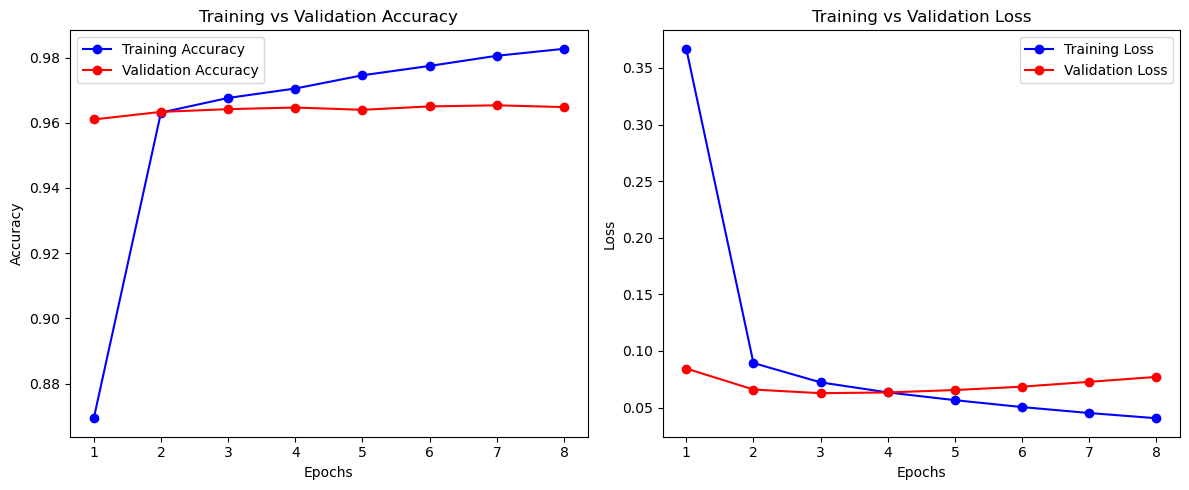

In [39]:
# Training and Validation Performance Visualization
acc = history.history['accuracy']
loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

# Number of epochs
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [40]:
# Model Evaluation
predictions_raw = model.predict(X_test)   # predicted probabilities for each class, shape (num_samples, num_classes)
y_pred = np.argmax(predictions_raw, axis=1) # convert probabilities to class labels (index of max prob), shape (num_samples,)

# Get the list of class names from the LabelEncoder (assuming 'le' is available)
class_names = le.classes_

acc = accuracy_score(y_test, y_pred)
# For multi-class ROC AUC, use predictions_raw (probabilities for each class) with 'ovr' strategy
auc = roc_auc_score(y_test, predictions_raw, multi_class='ovr', labels=np.arange(len(class_names)))

print(f"Test Accuracy : {acc:.4f}")
print(f"Test ROC-AUC  : {auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=class_names))

2462/2462 ━━━━━━━━━━━━━━━━━━━━ 99s 40ms/step 
Test Accuracy : 0.9647
Test ROC-AUC  : 0.9992

              precision    recall  f1-score   support

       anger       0.96      0.97      0.96     10937
        fear       0.95      0.93      0.94      8828
         joy       0.97      0.98      0.97     26981
        love       0.92      0.90      0.91      5827
     sadness       0.99      0.98      0.98     23669
    surprise       0.87      0.91      0.89      2523

    accuracy                           0.96     78765
   macro avg       0.94      0.95      0.94     78765
weighted avg       0.96      0.96      0.96     78765



In [41]:
# 738/738 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step
# Test Accuracy : 0.9310
# Test ROC-AUC  : 0.9971

#               precision    recall  f1-score   support

#        anger       0.90      0.97      0.94      3247
#         fear       0.93      0.86      0.89      2739
#          joy       0.95      0.94      0.95      7969
#         love       0.80      0.87      0.83      1915
#      sadness       0.97      0.97      0.97      6873
#     surprise       0.83      0.73      0.78       849

#     accuracy                           0.93     23592
#    macro avg       0.90      0.89      0.89     23592
# weighted avg       0.93      0.93      0.93     23592

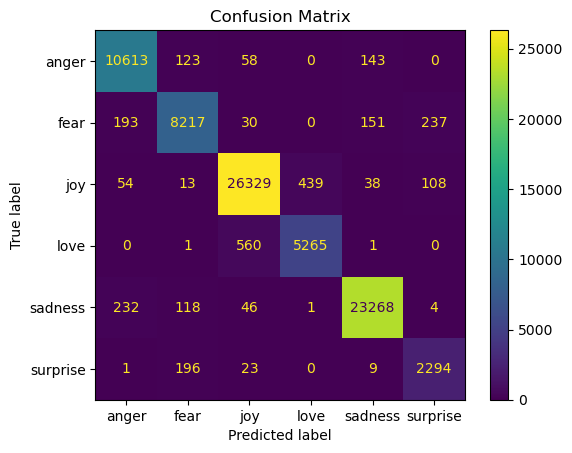

In [42]:
import matplotlib.pyplot as plt

# confusion Matrix
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=le.classes_)
plt.title('Confusion Matrix')
plt.show()

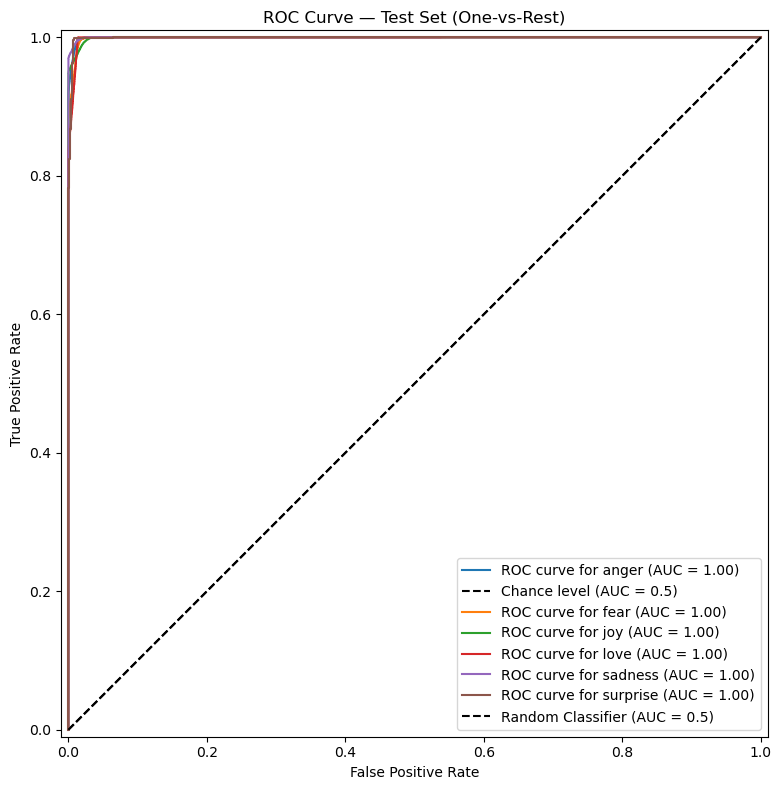

In [43]:
 # Plot ROC curve for each class
label_binarizer = LabelBinarizer()
y_test_onehot = label_binarizer.fit_transform(y_test)
class_names = le.classes_ # Get class names from LabelEncoder

plt.figure(figsize=(10, 8))

for i in range(len(class_names)):
   
    RocCurveDisplay.from_predictions(
        y_test_onehot[:, i], # True binary labels for current class
        predictions_raw[:, i], # Predicted probabilities for current class
        name=f"ROC curve for {class_names[i]}",
        ax=plt.gca(),
        plot_chance_level=(i == 0) # Only plot chance level once
    )

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)') # Plot random classifier line
plt.title('ROC Curve — Test Set (One-vs-Rest)')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Manual Testing

In [44]:
test_sentences = [
    "I am extremely happy today because I got my dream job.",
    "I feel very sad and lonely after losing my friend.",
    "I am so angry that I cannot control my emotions.",
    "I am scared about what will happen tomorrow.",
    "I am surprised by the amazing news I received.",
    "I feel calm and relaxed while listening to music.",
    "This movie made me laugh so much.",
    "I am disappointed with the results of my exam.",
    "I love spending time with my family.",
    "I hate how unfair this situation is.",
    "I never expected to win the competition!"
]
for sentence in test_sentences:
    seq = tokenizer.texts_to_sequences([sentence])
    padded = pad_sequences(seq, maxlen=200)

    prediction = model.predict(padded, verbose=0)
    emotion_index = np.argmax(prediction)

    predicted_emotion = le.inverse_transform([emotion_index])

    print("Sentence:", sentence)
    print("Predicted Emotion:", predicted_emotion[0])
    print("-" * 40)

Sentence: I am extremely happy today because I got my dream job.
Predicted Emotion: joy
----------------------------------------
Sentence: I feel very sad and lonely after losing my friend.
Predicted Emotion: sadness
----------------------------------------
Sentence: I am so angry that I cannot control my emotions.
Predicted Emotion: anger
----------------------------------------
Sentence: I am scared about what will happen tomorrow.
Predicted Emotion: fear
----------------------------------------
Sentence: I am surprised by the amazing news I received.
Predicted Emotion: joy
----------------------------------------
Sentence: I feel calm and relaxed while listening to music.
Predicted Emotion: joy
----------------------------------------
Sentence: This movie made me laugh so much.
Predicted Emotion: anger
----------------------------------------
Sentence: I am disappointed with the results of my exam.
Predicted Emotion: sadness
----------------------------------------
Sentence: I love 